# ДЗ №1. Парсинг датасета с сайта

## Задание

**Цель**:  
Необходимо написать свой парсер, который будет бегать по страничкам и автоматически что-то собирать.

**Описание/Пошаговая инструкция выполнения домашнего задания**:

1. Взять сайт, где можно собирать данные (желательно, чтобы API не предоставлялось)
2. Важно, чтобы объекту соответствовало текстовое описание и некая целевая переменная
3. Важно ограничить число запросов в секунду (time.sleep(0.3))
4. При необходимости очистить датасет от мусора с помощью регулярных выражений.
5. Посчитать статистики по собранным данным и провести EDA собранных данных
6. Если данные представляют собой текст — посчитать частотности слов, выявить наиболее частотные слова итд.
7. Сохранить полученный датасет для дальнейших дз

## Решение

Для данного задания был выбран сайт [YesNoGame](https://yesnogame.net)

Для каждой данетки можно выделить следующие параметры\характеристики:
* номер данетки - число, пользователю особо ничего не говорит, но по номеру можно восстановить url загадки
* название загадки - текст
* само условие - текст
* ответ - текст
* рейтинг - число, процент людей, которым понравилась данетка
* среднее время прохождения - число, минуты
* сложность - число, по 10-бальной шкале
* класс сложности - текст, "легкая"/"средняя"/"сложная"
* количество оценок - число оценивших загадку пользователей
* дата публикации - дата
* категории - текстовый список классов

Каждая данетка с номером N лежит по ссылке https://yesnogame.net/stories/N

## 1. Подготовка окружения

Подготовим библиотеки, которыми пользовались на лекциях


In [61]:
%pip install -q fake-useragent beautifulsoup4 lxml wordcloud tqdm


In [62]:
import re
import time
import warnings
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from fake_useragent import UserAgent
from tqdm.auto import tqdm
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_colwidth', 200)


## 2. Парсинг

Если посмотреть на страничку с данеткой, например https://yesnogame.net/stories/1, можно заметить, что номер данетки указан в урле. Так же можно заметить, что присутствует кнопка "к следующей данетке", но там кажется рандомный номер подставляется.

Для данной работы я принял решение ходить просто по урлу с самого начала, те с 1го номера и последовательно опрашивать сайт.

Заметил некоторую проблему - 2, 6, 7 и кто знает каких ещё данеток не существует, сайт выдает 404. Поэтому будем идти последовательно, но при этом остановим парсинг если случилось достаточно много 404 кодов.

Из приятного - каждая данетка имеет строгую одинаковую структуру, что облегчает парсинг...


In [63]:
BASE_URL = 'https://yesnogame.net'
RIDDLE_PREFIX = f'{BASE_URL}/stories'

REQUEST_DELAY = 0.3
TIMEOUT = 10

session = requests.Session()
session.headers.update({
    'User-Agent': UserAgent().chrome,
})

def get_response(url: str) -> requests.Response:
    time.sleep(REQUEST_DELAY)
    response = session.get(url, timeout=TIMEOUT)
    return response

def get_soup(url: str):
    response = get_response(url)
    if response.status_code != 200:
        return None, response
    return BeautifulSoup(response.text, 'lxml'), response

### Проверка первой данетки


In [64]:
demo_url = f'{RIDDLE_PREFIX}/1'
demo_soup, demo_res = get_soup(demo_url)


In [65]:
print('status code:', demo_res.status_code)

print('\n1. название данетки\n')
title = demo_soup.find('h1', attrs={'class': 'quest__title'})
print(title.contents)
print(title.contents[-1].strip())

print('\n2. условие\n')
riddle = demo_soup.find('div', attrs={'class': 'quest__story_question'})
print(riddle.contents)
print(riddle.get_text(strip=True))

print('\n3. ответ\n')
answer = demo_soup.find('div', attrs={'class': 'quest__story_answer'})
print(answer.contents)
print(answer.get_text(strip=True))

stats = demo_soup.find('div', attrs={'id': 'story-statistic'})
print('\n\nSTATISTICS:\n\n', stats.contents)

stat_values = [div.get_text(strip=True) for div in stats.find_all('div', attrs={'class': 'quest__about__value'})]
stat_titles = [div.get_text(strip=True) for div in stats.find_all('div', attrs={'class': 'quest__about__title'})]

print('\n4. рейтинг\n')
print(stat_values[0])

print('\n5. среднее время прохождения\n')
print(stat_values[1])

print('\n6. сложность\n')
print(stat_values[2])

print('\n7. количество оценок\n')
print(stat_titles[2])

print('\n8. дата публикации\n')
print(stat_values[3])

print('\n9. категории\n')
tags = demo_soup.find('ul', attrs={'class': 'tags__list'})
tags_names = [div.get_text(strip=True) for div in tags.find_all('a', attrs={'class': 'tags__link'})]
print(tags.contents)
print(tags_names)


status code: 200

1. название данетки

[<span class="pre-title">Данетка</span>, 'Человек со спичкой']
Человек со спичкой

2. условие

['\n', <div class="quest__story__text">
<p>Голый человек был найден мертвым посреди пустыни. В его руке была сгоревшая спичка. Что произошло?</p>
</div>, '\n']
Голый человек был найден мертвым посреди пустыни. В его руке была сгоревшая спичка. Что произошло?

3. ответ

['\n', <div class="quest__story__text">
<p>Человек летел с другими людьми на воздушном шаре. Воздушный шар начал падать и чтобы сделать его легче, они выкинули все вещи, в том числе всю свою одежду. Этого было недостаточно и они решили, что один из них должен прыгнуть для спасения остальных. Они договорились тянуть спичку: кому выпадет сгоревшая спичка, тому придется прыгать. Этому человеку попалась сгоревшая спичка и он прыгнул, как они и договаривались.</p>
</div>, '\n']
Человек летел с другими людьми на воздушном шаре. Воздушный шар начал падать и чтобы сделать его легче, они выкинули в

### Сбор ссылок на данетки

In [66]:
def collect_riddle_urls(max_riddle_id: int = 500, max_404s: int = 30) -> list:
    """
    Обходим номера данеток и собираем существующие ссылки.
    Если подряд вернулось много 404 - останавливаемся.
    """
    riddle_urls = []
    misses = 0

    for riddle_id in tqdm(range(1, max_riddle_id + 1), desc='Сбор ссылок'):
        url = f'{RIDDLE_PREFIX}/{riddle_id}'
        try:
            response = get_response(url)
        except Exception as e:
            print(f'get_response error for {url}: {e}')
            misses += 1
            if misses >= max_404s:
                print(f'stop after {misses} misses')
                break
            continue

        if response.status_code != 200:
            misses += 1
            if misses >= max_404s:
                print(f'stop after {misses} misses')
                break
        else:
            riddle_urls.append(response.url)
            misses = 0

    return list(dict.fromkeys(riddle_urls))

riddle_urls = collect_riddle_urls()
print('Найдено ссылок на данетки: ', len(riddle_urls))
riddle_urls[:20]


Сбор ссылок:   0%|          | 0/500 [00:00<?, ?it/s]

stop after 30 misses
Найдено ссылок на данетки:  244


['https://yesnogame.net/stories/1',
 'https://yesnogame.net/stories/3',
 'https://yesnogame.net/stories/4',
 'https://yesnogame.net/stories/5',
 'https://yesnogame.net/stories/8',
 'https://yesnogame.net/stories/9',
 'https://yesnogame.net/stories/10',
 'https://yesnogame.net/stories/11',
 'https://yesnogame.net/stories/12',
 'https://yesnogame.net/stories/13',
 'https://yesnogame.net/stories/14',
 'https://yesnogame.net/stories/15',
 'https://yesnogame.net/stories/16',
 'https://yesnogame.net/stories/17',
 'https://yesnogame.net/stories/19',
 'https://yesnogame.net/stories/21',
 'https://yesnogame.net/stories/22',
 'https://yesnogame.net/stories/24',
 'https://yesnogame.net/stories/25',
 'https://yesnogame.net/stories/27']

### Парсинг одной данетки


In [67]:
def parse_page(url: str) -> dict:
    soup, response = get_soup(url)
    if response.status_code != 200 or soup is None:
        raise ValueError(f'Не удалось открыть {url}: {response.status_code}')

    title_el = soup.find('h1', attrs={'class': 'quest__title'})
    title = title_el.contents[-1].strip()

    riddle_el = soup.find('div', attrs={'class': 'quest__story_question'})
    riddle = riddle_el.get_text(strip=True)

    answer_el = soup.find('div', attrs={'class': 'quest__story_answer'})
    answer = answer_el.get_text(strip=True)

    stats_el = soup.find('div', attrs={'id': 'story-statistic'})
    stat_values = [div.get_text(strip=True) for div in stats_el.find_all('div', attrs={'class': 'quest__about__value'})]
    stat_titles = [div.get_text(strip=True) for div in stats_el.find_all('div', attrs={'class': 'quest__about__title'})]
    like_rate_str = stat_values[0]
    avg_time_str = stat_values[1]
    difficulty_str = stat_values[2]
    votes_str = stat_titles[2]
    publication_date_str = stat_values[3]
    tags_el = soup.find('ul', attrs={'class': 'tags__list'})
    tags_names = [div.get_text(strip=True) for div in tags_el.find_all('a', attrs={'class': 'tags__link'})]

    like_rate = re.search(r'\d+', like_rate_str).group()
    avg_time = re.search(r'\d+', avg_time_str).group()
    difficulty_match = re.search(r'(\d+)\/\d+\s+(.+)', difficulty_str)
    difficulty_value = difficulty_match.group(1)
    difficulty_class_rus = difficulty_match.group(2).lower()
    if difficulty_class_rus.startswith('легк'):
        difficulty_class = 'easy'
    elif difficulty_class_rus.startswith('средн'):
        difficulty_class = 'medium'
    elif difficulty_class_rus.startswith('сложн'):
        difficulty_class = 'hard'
    else:
        difficulty_class = None
    votes = re.search(r'\d+', votes_str).group()

    months = {
        'января': '01',
        'февраля': '02',
        'марта': '03',
        'апреля': '04',
        'мая': '05',
        'июня': '06',
        'июля': '07',
        'августа': '08',
        'сентября': '09',
        'октября': '10',
        'ноября': '11',
        'декабря': '12'
    }
    day, month, year = re.search(r'(\d{2})\s+(\w+)\s+(\d{4})', publication_date_str).groups()
    date_obj = datetime.strptime(f'{day}.{months[month]}.{year}', '%d.%m.%Y')
    publication_date = date_obj.strftime("%d.%m.%y")

    return {
        'url': response.url,
        'id': int(response.url.split('/')[-1]),
        'title': title,
        'riddle': riddle,
        'answer': answer,
        'like_rate': int(like_rate),
        'avg_time': int(avg_time),
        'difficulty_value': int(difficulty_value),
        'difficulty_class': difficulty_class,
        'votes': int(votes),
        'publication_date': publication_date,
        'tags_names': tags_names
    }

example_story = parse_page(riddle_urls[1])
example_story

{'url': 'https://yesnogame.net/stories/3',
 'id': 3,
 'title': 'Последнее такси',
 'riddle': 'Эльдар сидел и читал газету, когда услышал шум. Когда он понял что произошло, он очень пожалел, что не поймал такси вовремя. Вскоре он покончил с собой.',
 'answer': 'Эльдар был разорен. Он был коллекционером масштабных моделей такси (уменьшенные копии автомобилей), и чтобы решить свои денежные проблемы он хотел продать самый дорогой экземпляр коллекции. Он почистил его и опрометчиво поставил на край стола. Во время чтения газеты он задел стол ногой, из-за чего такси скатилось со стола и упало на пол, разбившись. Другие экземпляры коллекции не были достаточно дорогими.',
 'like_rate': 72,
 'avg_time': 22,
 'difficulty_value': 8,
 'difficulty_class': 'hard',
 'votes': 2105,
 'publication_date': '04.01.18',
 'tags_names': ['детективные', 'про убийства', 'страшные']}

## 4. Сборка датасета

Здесь уже проходим по всем найденным ссылкам, парсим каждую страницу и складываем результаты в таблицу. При ошибках просто логируем проблемную ссылку и продолжаем работу.


In [68]:
records = []
failed_urls = []

for url in tqdm(riddle_urls, desc='Парсинг страниц'):
    try:
        records.append(parse_page(url))
    except Exception as error:
        failed_urls.append({'url': url, 'error': str(error)})

df = pd.DataFrame(records)
df['publication_date'] = pd.to_datetime(df['publication_date'], format="%d.%m.%y")
df = df.sort_values('id').reset_index(drop=True)

print('Размер датасета:', df.shape)
print('Ошибки парсинга:', failed_urls)
df.head()


Парсинг страниц:   0%|          | 0/244 [00:00<?, ?it/s]

Размер датасета: (239, 12)
Ошибки парсинга: [{'url': 'https://yesnogame.net/stories/218', 'error': "'NoneType' object has no attribute 'find_all'"}, {'url': 'https://yesnogame.net/stories/231', 'error': "'NoneType' object has no attribute 'find_all'"}, {'url': 'https://yesnogame.net/stories/239', 'error': "'NoneType' object has no attribute 'find_all'"}, {'url': 'https://yesnogame.net/stories/254', 'error': "'NoneType' object has no attribute 'find_all'"}, {'url': 'https://yesnogame.net/stories/343', 'error': "'NoneType' object has no attribute 'find_all'"}]


,url,id,title,riddle,answer,like_rate,avg_time,difficulty_value,difficulty_class,votes,publication_date,tags_names
0,https://yesnogame.net/stories/1,1,Человек со спичкой,Голый человек был найден мертвым посреди пустыни. В его руке была сгоревшая спичка. Что произошло?,"Человек летел с другими людьми на воздушном шаре. Воздушный шар начал падать и чтобы сделать его легче, они выкинули все вещи, в том числе всю свою одежду. Этого было недостаточно и они решили, чт...",78,18,7,hard,2849,2018-03-04,"[детективные, про убийства, страшные]"
1,https://yesnogame.net/stories/3,3,Последнее такси,"Эльдар сидел и читал газету, когда услышал шум. Когда он понял что произошло, он очень пожалел, что не поймал такси вовремя. Вскоре он покончил с собой.","Эльдар был разорен. Он был коллекционером масштабных моделей такси (уменьшенные копии автомобилей), и чтобы решить свои денежные проблемы он хотел продать самый дорогой экземпляр коллекции. Он поч...",72,22,8,hard,2105,2018-01-04,"[детективные, про убийства, страшные]"
2,https://yesnogame.net/stories/4,4,Открытая дверь,"Григорий проснулся рано утром и удивился, что дверь была открыта. Как только он перешел порог - его голова была оторвана.",Григорий был попугаем и жил в клетке несколько месяцев. Кот Борис всё это время ждал возможности поймать его и съесть. Как-то раз хозяева забыли закрыть клетку на ночь. На утро произошла трагедия.,79,11,5,medium,1794,2018-01-04,"[детективные, страшные, про убийства, для детей]"
3,https://yesnogame.net/stories/5,5,Случайный случай,"Водитель стал причиной несчастного случая, врезавшись в мотоцикл во время своего неожиданного поворота на перекрестке. Но когда полицейский приехал, был арестован другой человек. Водитель был осво...","Водитель был на уроке вождения со своим инструктором, который указал ему сделать неверный поворот, во время которого водитель врезался в ехавший мотоцикл. Полиция посчитала виновным инструктора и ...",81,11,4,medium,994,2018-01-04,"[на реальных событиях, детективные, страшные]"
4,https://yesnogame.net/stories/8,8,Темень,"Маргарита была на работе и спускалась по лестнице, когда внезапно потемнело. В этот момент она поняла, что её муж при смерти.","Маргарита работала электриком в больнице и знала, что аварийные генераторы не работают. Недавно её мужа сбила машина и он лежал в этой больнице с аппаратурой, поддерживающей его жизнь. Когда поте...",80,7,3,easy,1110,2018-01-04,"[детективные, страшные]"


## 5. Очистка и подготовка признаков

Отчистим текст загадок и ответов.
Добавим несколько удобных признаков: длины в словах и в символах.


In [69]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'[^а-яё0-9\s-]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['riddle_clean'] = df['riddle'].apply(clean_text)
df['answer_clean'] = df['answer'].apply(clean_text)
df['riddle_len_chars'] = df['riddle_clean'].str.len()
df['answer_len_chars'] = df['answer_clean'].str.len()
df['riddle_word_count'] = df['riddle_clean'].str.split().str.len()
df['answer_word_count'] = df['answer_clean'].str.split().str.len()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   url                239 non-null    object        
 1   id                 239 non-null    int64         
 2   title              239 non-null    object        
 3   riddle             239 non-null    object        
 4   answer             239 non-null    object        
 5   like_rate          239 non-null    int64         
 6   avg_time           239 non-null    int64         
 7   difficulty_value   239 non-null    int64         
 8   difficulty_class   239 non-null    object        
 9   votes              239 non-null    int64         
 10  publication_date   239 non-null    datetime64[ns]
 11  tags_names         239 non-null    object        
 12  riddle_clean       239 non-null    object        
 13  answer_clean       239 non-null    object        
 14  riddle_len

In [70]:
df.head()

,url,id,title,riddle,answer,like_rate,avg_time,difficulty_value,difficulty_class,votes,publication_date,tags_names,riddle_clean,answer_clean,riddle_len_chars,answer_len_chars,riddle_word_count,answer_word_count
0,https://yesnogame.net/stories/1,1,Человек со спичкой,Голый человек был найден мертвым посреди пустыни. В его руке была сгоревшая спичка. Что произошло?,"Человек летел с другими людьми на воздушном шаре. Воздушный шар начал падать и чтобы сделать его легче, они выкинули все вещи, в том числе всю свою одежду. Этого было недостаточно и они решили, чт...",78,18,7,hard,2849,2018-03-04,"[детективные, про убийства, страшные]",голый человек был найден мертвым посреди пустыни в его руке была сгоревшая спичка что произошло,человек летел с другими людьми на воздушном шаре воздушный шар начал падать и чтобы сделать его легче они выкинули все вещи в том числе всю свою одежду этого было недостаточно и они решили что оди...,95,405,15,65
1,https://yesnogame.net/stories/3,3,Последнее такси,"Эльдар сидел и читал газету, когда услышал шум. Когда он понял что произошло, он очень пожалел, что не поймал такси вовремя. Вскоре он покончил с собой.","Эльдар был разорен. Он был коллекционером масштабных моделей такси (уменьшенные копии автомобилей), и чтобы решить свои денежные проблемы он хотел продать самый дорогой экземпляр коллекции. Он поч...",72,22,8,hard,2105,2018-01-04,"[детективные, про убийства, страшные]",эльдар сидел и читал газету когда услышал шум когда он понял что произошло он очень пожалел что не поймал такси вовремя вскоре он покончил с собой,эльдар был разорен он был коллекционером масштабных моделей такси уменьшенные копии автомобилей и чтобы решить свои денежные проблемы он хотел продать самый дорогой экземпляр коллекции он почистил...,146,398,26,60
2,https://yesnogame.net/stories/4,4,Открытая дверь,"Григорий проснулся рано утром и удивился, что дверь была открыта. Как только он перешел порог - его голова была оторвана.",Григорий был попугаем и жил в клетке несколько месяцев. Кот Борис всё это время ждал возможности поймать его и съесть. Как-то раз хозяева забыли закрыть клетку на ночь. На утро произошла трагедия.,79,11,5,medium,1794,2018-01-04,"[детективные, страшные, про убийства, для детей]",григорий проснулся рано утром и удивился что дверь была открыта как только он перешел порог - его голова была оторвана,григорий был попугаем и жил в клетке несколько месяцев кот борис всё это время ждал возможности поймать его и съесть как-то раз хозяева забыли закрыть клетку на ночь на утро произошла трагедия,118,192,20,32
3,https://yesnogame.net/stories/5,5,Случайный случай,"Водитель стал причиной несчастного случая, врезавшись в мотоцикл во время своего неожиданного поворота на перекрестке. Но когда полицейский приехал, был арестован другой человек. Водитель был осво...","Водитель был на уроке вождения со своим инструктором, который указал ему сделать неверный поворот, во время которого водитель врезался в ехавший мотоцикл. Полиция посчитала виновным инструктора и ...",81,11,4,medium,994,2018-01-04,"[на реальных событиях, детективные, страшные]",водитель стал причиной несчастного случая врезавшись в мотоцикл во время своего неожиданного поворота на перекрестке но когда полицейский приехал был арестован другой человек водитель был освобожден,водитель был на уроке вождения со своим инструктором который указал ему сделать неверный поворот во время которого водитель врезался в ехавший мотоцикл полиция посчитала виновным инструктора и аре...,198,228,26,32
4,https://yesnogame.net/stories/8,8,Темень,"Маргарита была на работе и спускалась по лестнице, когда внезапно потемнело. В этот момент она поняла, что её муж при смерти.","Маргарита работала электриком в больнице и знала, что аварийные генераторы не работают. Недавно её мужа сбила машина и он лежал в этой больнице с аппаратурой, поддерживающей его жизнь. Когда поте...",80,7,3,easy,1110,2018-01-04,"[детективные, страшные]",маргарита была на работе и спускалась по лестнице когда внезап

In [71]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,239.0,202.874477,1.0,145.5,205.0,275.5,417.0,100.561036
like_rate,239.0,74.535565,35.0,71.0,76.0,82.0,88.0,9.352447
avg_time,239.0,13.121339,3.0,8.0,12.0,17.0,39.0,6.428495
difficulty_value,239.0,4.995816,1.0,4.0,5.0,6.0,9.0,1.742928
votes,239.0,720.585774,13.0,135.5,279.0,758.5,10985.0,1223.427325
publication_date,239,2020-02-19 08:32:08.033472768,2018-01-04 00:00:00,2018-03-03 00:00:00,2019-08-11 00:00:00,2022-02-05 00:00:00,2023-12-22 00:00:00,NaN
riddle_len_chars,239.0,166.472803,36.0,83.0,128.0,185.0,1342.0,161.463782
answer_len_chars,239.0,240.589958,20.0,110.0,201.0,304.0,1359.0,194.070353
riddle_word_count,239.0,27.564854,5.0,14.0,20.0,31.0,234.0,27.82665
answer_word_count,239.0,38.221757,3.0,16.5,33.0,47.0,209.0,30.707433


## 6. EDA

Здесь рассомтрим
- гистограммы числовых признаков
- самые популярные категории
- самые частотные слова в условиях/ответах данеток
- корреляцию числовых признаков

### Гистограммы числовых признаков

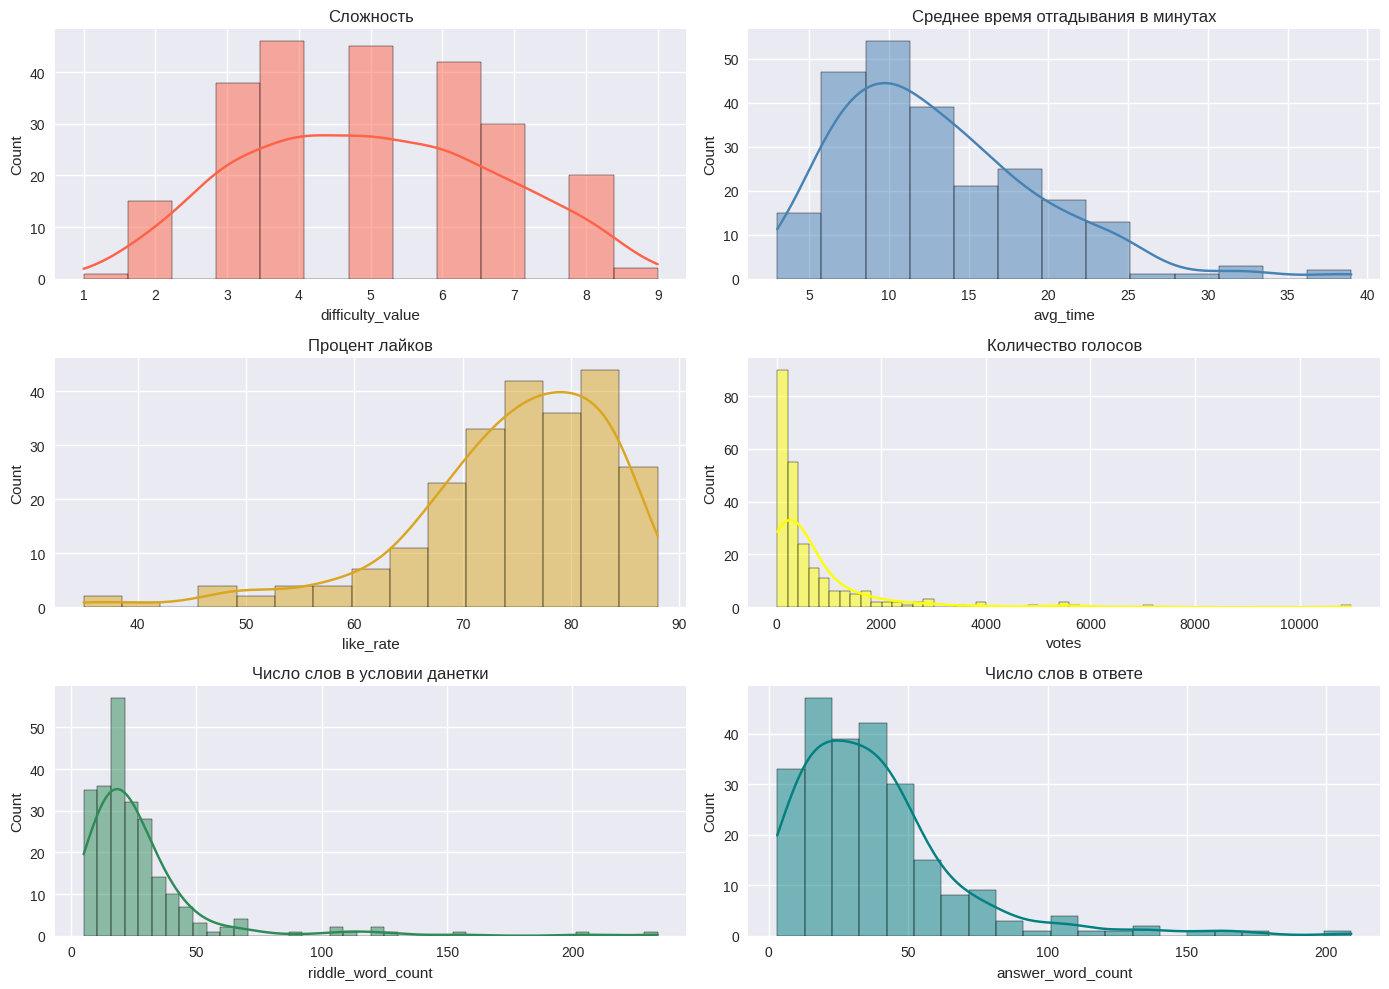

In [72]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

sns.histplot(df['difficulty_value'].dropna(), kde=True, ax=axes[0, 0], color='tomato')
axes[0, 0].set_title('Cложность')

sns.histplot(df['avg_time'].dropna(), kde=True, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Среднее время отгадывания в минутах')

sns.histplot(df['like_rate'].dropna(), kde=True, ax=axes[1, 0], color='goldenrod')
axes[1, 0].set_title('Процент лайков')

sns.histplot(df['votes'].dropna(), kde=True, ax=axes[1, 1], color='yellow')
axes[1, 1].set_title('Количество голосов')

sns.histplot(df['riddle_word_count'].dropna(), kde=True, ax=axes[2, 0], color='seagreen')
axes[2, 0].set_title('Число слов в условии данетки')

sns.histplot(df['answer_word_count'].dropna(), kde=True, ax=axes[2, 1], color='teal')
axes[2, 1].set_title('Число слов в ответе')

plt.tight_layout()
plt.show()


### Самые популярные категории

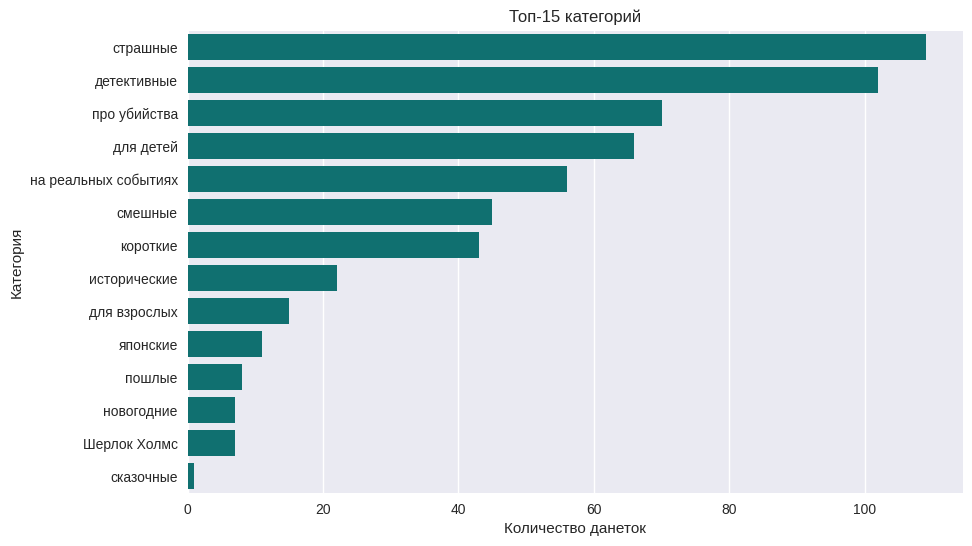

In [73]:
categories_df = (
    df[['id', 'tags_names']]
        .explode('tags_names')
        .dropna()
        .rename(columns={'tags_names': 'category'})
)

top_categories = categories_df['category'].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, color='teal')
plt.title('Топ-15 категорий')
plt.xlabel('Количество данеток')
plt.ylabel('Категория')
plt.show()


### Частотность слов

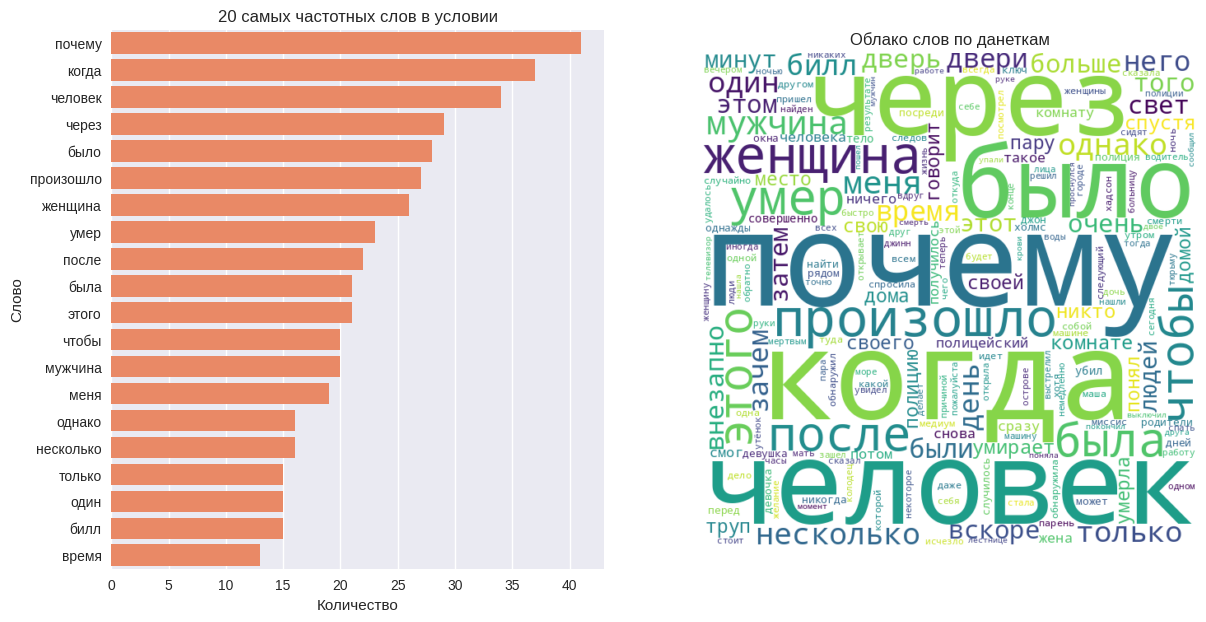

In [74]:
tokens = re.findall(r'[а-яё]{4,}', ' '.join(df['riddle_clean'].dropna().tolist()).lower())

freq = Counter(tokens)
freq_df = pd.DataFrame(freq.most_common(20), columns=['word', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sns.barplot(data=freq_df, x='count', y='word', color='coral', ax=axes[0])
axes[0].set_title('20 самых частотных слов в условии')
axes[0].set_xlabel('Количество')
axes[0].set_ylabel('Слово')

wordcloud = WordCloud(
    width=600,
    height=600,
    background_color='white',
    collocations=False
).generate_from_frequencies(freq)

axes[1].set_title('Облако слов по данеткам')
axes[1].imshow(wordcloud, interpolation='bilinear')
axes[1].axis('off')

plt.show()


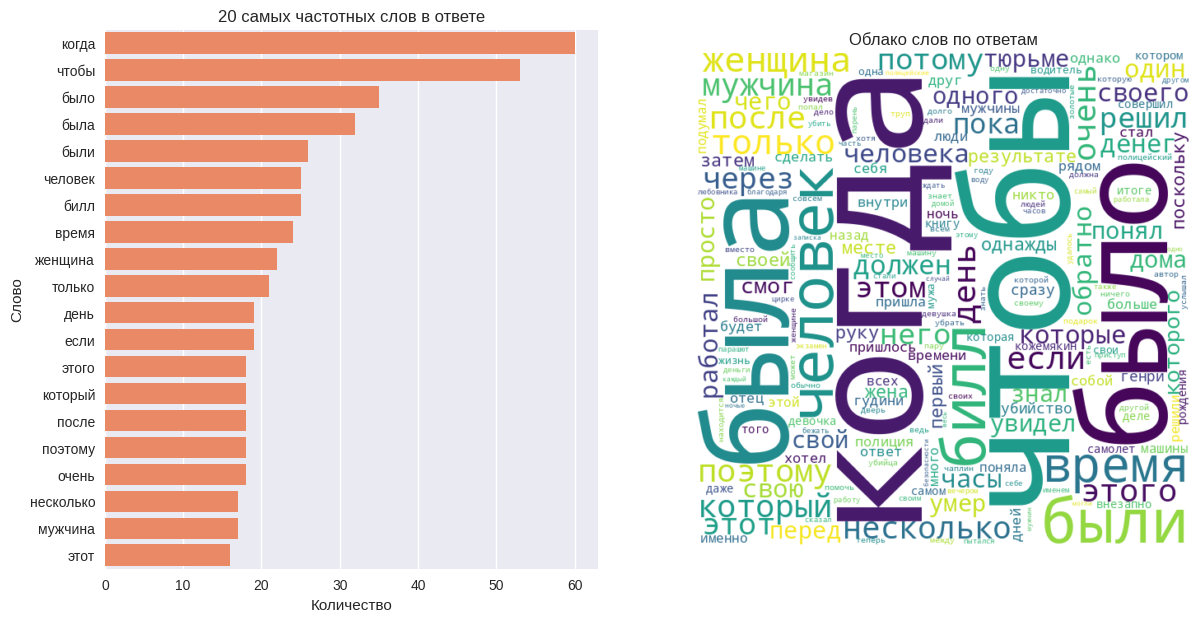

In [75]:
tokens = re.findall(r'[а-яё]{4,}', ' '.join(df['answer_clean'].dropna().tolist()).lower())

freq = Counter(tokens)
freq_df = pd.DataFrame(freq.most_common(20), columns=['word', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sns.barplot(data=freq_df, x='count', y='word', color='coral', ax=axes[0])
axes[0].set_title('20 самых частотных слов в ответе')
axes[0].set_xlabel('Количество')
axes[0].set_ylabel('Слово')

wordcloud = WordCloud(
    width=600,
    height=600,
    background_color='white',
    collocations=False
).generate_from_frequencies(freq)

axes[1].set_title('Облако слов по ответам')
axes[1].imshow(wordcloud, interpolation='bilinear')
axes[1].axis('off')

plt.show()


### Корреляция признаков

,like_rate,avg_time,difficulty_value,votes,riddle_word_count,answer_word_count
like_rate,1.000000,-0.224929,-0.011977,0.355829,-0.165959,0.009255
avg_time,-0.224929,1.000000,0.879802,-0.000633,-0.067068,0.678338
difficulty_value,-0.011977,0.879802,1.000000,0.091521,-0.087190,0.651770
votes,0.355829,-0.000633,0.091521,1.000000,-0.070877,0.005710
riddle_word_count,-0.165959,-0.067068,-0.087190,-0.070877,1.000000,-0.029734
answer_word_count,0.009255,0.678338,0.651770,0.005710,-0.029734,1.000000


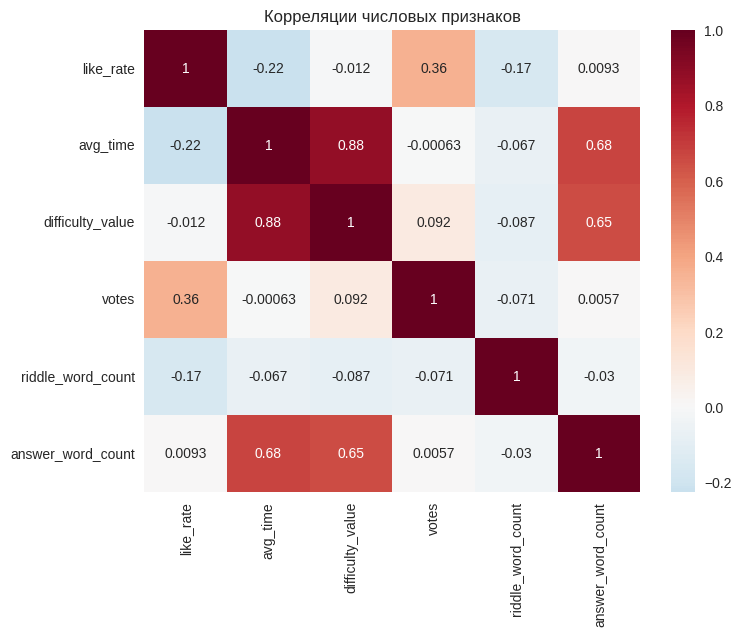

In [76]:
plt.figure(figsize=(8, 6))
numeric_cols = ['like_rate', 'avg_time', 'difficulty_value', 'votes', 'riddle_word_count', 'answer_word_count']
corr = df[numeric_cols].corr(numeric_only=True)
display(corr)
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Корреляции числовых признаков')
plt.show()


## 7. Сохранение датасета

Сохраним результат в `.csv` и `.json`


In [77]:
csv_path = 'danetki_dataset.csv'
json_path = 'danetki_dataset.json'

df.to_csv(csv_path, index=False, encoding='utf-8-sig')
df.to_json(json_path, orient='records', force_ascii=False, indent=2)

print('Сохранено:')
print(csv_path)
print(json_path)

Сохранено:
danetki_dataset.csv
danetki_dataset.json


In [78]:
from google.colab import files

files.download("danetki_dataset.csv")
files.download("danetki_dataset.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>